In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime

In [6]:

class GasTradingEngine:
    def __init__(self, csv_filename):
        self.df = pd.read_csv(csv_filename)
        
        # FIXED: Changed %Y to %y to match your "10/31/20" data format
        self.df['Dates'] = pd.to_datetime(self.df['Dates'], format='%m/%d/%y')
        self.df['Prices'] = self.df['Prices'].astype(float)
        
        self.model = LinearRegression()
        self.start_date = self.df['Dates'].min()
        self._train_model()

    def _prepare_features(self, date_series):
        days_from_start = (date_series - self.start_date).dt.days
        day_of_year = date_series.dt.dayofyear
        sin_seasonal = np.sin(2 * np.pi * day_of_year / 365.25)
        cos_seasonal = np.cos(2 * np.pi * day_of_year / 365.25)
        
        return pd.DataFrame({
            'trend': days_from_start,
            'sin': sin_seasonal,
            'cos': cos_seasonal
        })

    def _train_model(self):
        X = self._prepare_features(self.df['Dates'])
        y = self.df['Prices']
        self.model.fit(X, y)

    def get_price(self, date_string):
        target_dt = pd.to_datetime(date_string)
        features = self._prepare_features(pd.Series([target_dt]))
        return self.model.predict(features)[0]

    def price_contract(self, injection_dates, injection_volumes, 
                       withdrawal_dates, withdrawal_volumes, 
                       storage_rate, max_capacity, inj_wit_fee):
        
        total_buy_cost = 0
        total_sell_revenue = 0
        total_fees = 0
        current_inventory = 0
        
        # Calculate Injections
        for date, vol in zip(injection_dates, injection_volumes):
            if current_inventory + vol > max_capacity:
                raise ValueError(f"Limit Alert: Facility full on {date}")
            p = self.get_price(date)
            total_buy_cost += p * vol
            total_fees += inj_wit_fee * vol
            current_inventory += vol
            
        # Calculate Withdrawals
        for date, vol in zip(withdrawal_dates, withdrawal_volumes):
            if current_inventory - vol < 0:
                raise ValueError(f"Inventory Alert: Not enough gas on {date}")
            p = self.get_price(date)
            total_sell_revenue += p * vol
            total_fees += inj_wit_fee * vol
            current_inventory -= vol
            
        # Calculate Storage Duration
        all_dates = pd.to_datetime(injection_dates + withdrawal_dates)
        months = (all_dates.max().year - all_dates.min().year) * 12 + \
                 (all_dates.max().month - all_dates.min().month)
        
        storage_costs = max(1, months) * storage_rate
        return round(total_sell_revenue - total_buy_cost - total_fees - storage_costs, 2)

# --- EXECUTION ---
if __name__ == "__main__":
    try:
        engine = GasTradingEngine('Nat_GasData.csv')
        
        # Test Scenario: 1M Injection in June, 1M Withdrawal in Dec
        val = engine.price_contract(
            injection_dates=['2025-06-01'], 
            injection_volumes=[1000000],
            withdrawal_dates=['2025-12-15'], 
            withdrawal_volumes=[1000000],
            storage_rate=100000, 
            max_capacity=2000000, 
            inj_wit_fee=0.01
        )
        
        print(f"--- SUCCESS ---")
        print(f"Contract NPV: ${val:,.2f}")
        
    except Exception as e:
        print(f"Error: {e}")

--- SUCCESS ---
Contract NPV: $451,238.80


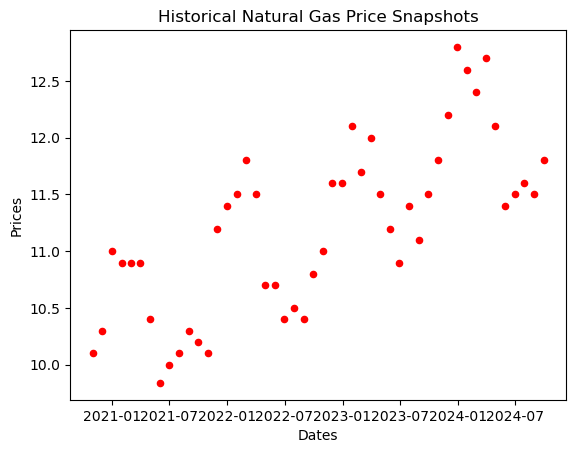

In [8]:
engine.df.plot(x='Dates', y='Prices', kind='scatter', color='red', title='Historical Natural Gas Price Snapshots')
plt.show()